<a href="https://colab.research.google.com/github/AlvPD/PE-y-RN/blob/main/Toggle_Switch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
# Se importan las librerias necesarias
import numpy as np
import math
import random as rnd
import matplotlib.pyplot as plt

In [112]:
#condiciones iniciales
t0=0.0
r1_0 = 50.0
r2_0 = 50.0

In [113]:
#parametros
Omega = 20.         # Volumen
alpha = 50.0        # Tasa de síntesis máxima
beta = 1.0          # Tasa de degradación
K_R = 0.5           # Constante de disociación
n = 4.0             # Coeficiente de Hill (n > 1)
Steps = 100000

In [114]:
# Se define la Matriz estequiométrica S
S = [[1., 0., -1., 0.], [0., 1., 0., -1.]]
# Se inicializa los vectores solucion y el tiempo
Y = np.zeros([2, Steps+1])
t = np.zeros(Steps+1)
# Se inicializan las condiciones iniciales
Y[0, 0] = r1_0
Y[1, 0] = r2_0

In [115]:
def dist_exp(a):
    """Genera numero aleatorio de distribucion exponencial para el tiempo tau"""
    r = rnd.random()
    return -(1./a)*math.log(r)

def dist_reaction(ni, A):
    """Elige la reacción basada en propensiones"""
    r = rnd.random()
    threshold = 0
    for i in range(len(ni)):
        threshold += ni[i]
        if r < threshold / A:
            return i
    return len(ni) - 1

In [116]:
#ciclo del algoritmo
for i in range(Steps):
    # Estado actual
    r1 = Y[0, i]
    r2 = Y[1, i]

    # Definición de funciones de Hill
    # g_R(x) = 1 / (1 + (x/K)^n)
    gR_r2 = 1.0 / (1.0 + ( (r2/Omega) / K_R )**n)
    gR_r1 = 1.0 / (1.0 + ( (r1/Omega) / K_R )**n)

    # Se actualiza vector de propensiones ni
    # Orden: [Sint_r1, Sint_r2, Deg_r1, Deg_r2]
    ni = np.array([
        alpha * gR_r2,          # Reacción 1
        alpha * gR_r1,          # Reacción 2
        beta * (r1/Omega),      # Reacción 3
        beta * (r2/Omega)       # Reacción 4
    ])

    # Se actualiza tasa de reaccion global
    a = sum(ni)

    # Evitar división por cero
    if a == 0:
        break

    # Se elige aleatoriamente tiempo de reaccion
    tau = dist_exp(a)

    # Se elige la reaccion que se llevara a cabo
    mu = dist_reaction(ni, a)

    # Se actualiza el estado del sistema y se avanza el tiempo
    Y[0, i+1] = Y[0, i] + S[0][mu]
    Y[1, i+1] = Y[1, i] + S[1][mu]
    t[i+1] = t[i] + tau

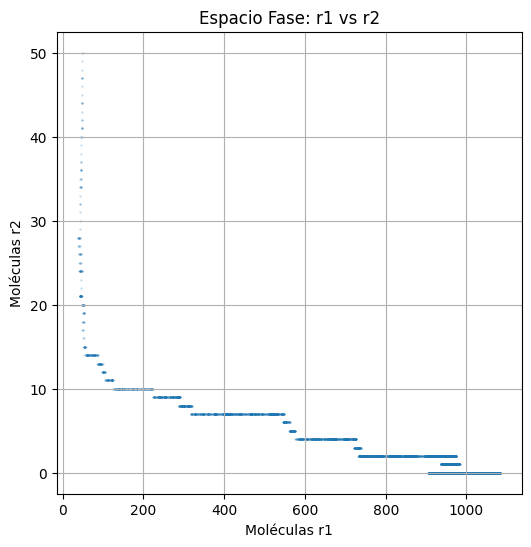

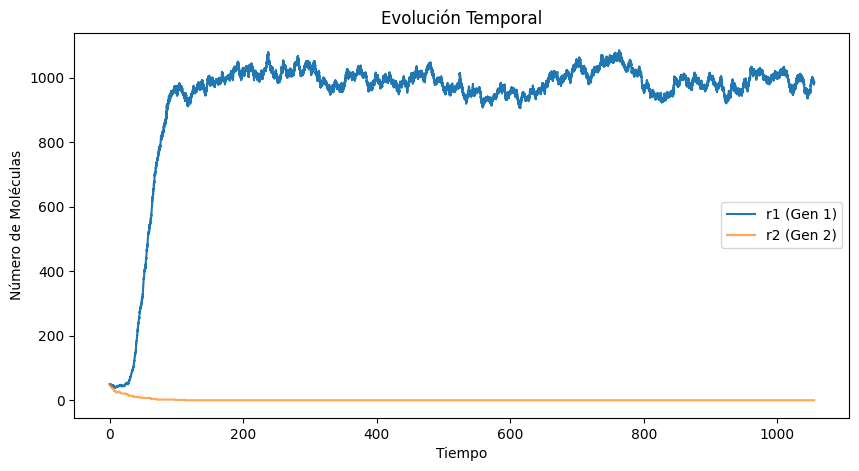

In [117]:
# Espacio fase (r1 vs r2)
plt.figure(figsize=(6, 6))
plt.scatter(Y[0], Y[1], s=0.1, alpha=0.5)
plt.title('Espacio Fase: r1 vs r2')
plt.xlabel('Moléculas r1')
plt.ylabel('Moléculas r2')
plt.grid(True)

# Evolución temporal
plt.figure(figsize=(10, 5))
plt.plot(t, Y[0], label='r1 (Gen 1)')
plt.plot(t, Y[1], label='r2 (Gen 2)', alpha=0.7)
plt.title('Evolución Temporal')
plt.xlabel('Tiempo')
plt.ylabel('Número de Moléculas')
plt.legend()

plt.show()

Did you found spontaneous switching in the stochastic simulations?

  Sí, se encuentran cambios espontáneos en las simulaciones si Ω es lo suficientemente pequeño (Ω< 1). A medida que aumentas Ω, el ruido relativo disminuye (∝1/Ω​) y los cambios se vuelven exponencialmente menos frecuentes